# 04 — Modeling & Evaluation

This notebook builds and evaluates predictive models for NBA game outcome classification using the model-ready feature table from notebook 03. Every feature is a pre-game statistic — no current-game box-score data leaks into the predictors.

**Goal:** Predict `is_win` (1 = win, 0 = loss) for each team-game row using historical form, schedule context, and opponent quality known before tip-off.

**Sections**
1. Setup & data loading
2. Data overview with DuckDB
3. Feature selection
4. Time-aware train/test split
5. Preprocessing
6. Evaluation utility
7. Baseline: always-predict-home rule
8. Logistic Regression
9. Random Forest
10. XGBoost
11. Hyperparameter tuning *(Difficulty Concept 1)*
12. Model comparison, ROC curves, and confusion matrices
13. Feature importance *(Difficulty Concept 2)*
14. Bootstrap confidence intervals
15. Conclusion & discussion

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='whitegrid', context='notebook')

PROCESSED_DIR = Path('data/processed')
MODEL_READY_PATH = PROCESSED_DIR / 'modeling_dataset.csv'
DICTIONARY_PATH  = PROCESSED_DIR / 'feature_dictionary.csv'

# Every figure in this notebook is auto-saved to OUTPUT_DIR so plots can be reviewed
# outside the notebook (e.g. for the presentation slides) without re-running cells.
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

def save_and_show(filename, dpi=150):
    """Save the current matplotlib figure to OUTPUT_DIR, then display it."""
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {path}')

# Seasons with season_start_year < TRAIN_CUTOFF go to train (2001-02 through 2019-20).
# Seasons with season_start_year >= TRAIN_CUTOFF go to test  (2020-21 through 2024-25).
TRAIN_CUTOFF  = 2020
RANDOM_STATE  = 42

print(f'XGBoost version : {xgb.__version__}')
print(f'DuckDB  version : {duckdb.__version__}')
print(f'Output directory: {OUTPUT_DIR.resolve()}')
print('All imports successful.')

XGBoost version : 3.1.2
DuckDB  version : 1.5.2
Output directory: C:\Users\Michel\OneDrive\Projects\cis5450-project\output
All imports successful.


## 1. Setup & Data Loading

Load the model-ready dataset produced by notebook 03 and run a quick integrity check. The CSV was saved with zero missing values in all numeric feature columns, which we verify before proceeding.

In [2]:
modeling_df = pd.read_csv(
    MODEL_READY_PATH,
    dtype={'GAME_ID': 'string', 'SEASON_YEAR': 'string'},
    parse_dates=['GAME_DATE'],
)
feature_dict = pd.read_csv(DICTIONARY_PATH)

# Sanity checks carried over from notebook 03
assert modeling_df.shape[0] == 56856, f'Unexpected row count: {modeling_df.shape[0]}'
assert modeling_df['is_win'].isna().sum() == 0, 'Missing target values found'

numeric_feature_cols = feature_dict.loc[
    feature_dict['role'].str.contains('feature'),
    'column'
].tolist()
numeric_feature_cols = [c for c in numeric_feature_cols if c in modeling_df.columns]
missing_count = modeling_df[numeric_feature_cols].isna().sum().sum()
assert missing_count == 0, f'Missing feature values: {missing_count}'

min_season = modeling_df['SEASON_YEAR'].min()
max_season = modeling_df['SEASON_YEAR'].max()

print(f'Rows    : {modeling_df.shape[0]:,}')
print(f'Columns : {modeling_df.shape[1]}')
print(f'Seasons : {min_season} through {max_season}')
print('All integrity checks passed.')

Rows    : 56,856
Columns : 260
Seasons : 2001-02 through 2024-25
All integrity checks passed.


## 2. Data Overview with DuckDB

DuckDB lets us run SQL directly on the pandas DataFrame without copying data. We use it here to inspect the season-level distribution, verify class balance, and preview the intended train/test split — all in a single readable query.

In [3]:
con = duckdb.connect()
con.register('modeling_data', modeling_df)

season_overview = con.execute("""
    SELECT
        SEASON_YEAR,
        season_start_year,
        COUNT(*)                                   AS team_game_rows,
        COUNT(DISTINCT GAME_ID)                    AS games,
        ROUND(AVG(is_win)          * 100, 1)       AS win_pct,
        ROUND(AVG(CAST(is_home AS DOUBLE)) * 100, 1) AS home_row_pct,
        CASE
            WHEN season_start_year < 2020 THEN 'Train'
            ELSE 'Test'
        END AS split
    FROM modeling_data
    GROUP BY SEASON_YEAR, season_start_year
    ORDER BY season_start_year
""").df()

display(season_overview)

,SEASON_YEAR,season_start_year,team_game_rows,games,win_pct,home_row_pct,split
0,2001-02,2001,2344,1172,50.0000,50.0000,Train
1,2002-03,2002,2344,1172,50.0000,50.0000,Train
2,2003-04,2003,2344,1172,50.0000,50.0000,Train
3,2004-05,2004,2424,1212,50.0000,50.0000,Train
4,2005-06,2005,2424,1212,50.0000,50.0000,Train
5,2006-07,2006,2426,1213,50.0000,50.0000,Train
6,2007-08,2007,2422,1211,50.0000,50.0000,Train
7,2008-09,2008,2426,1213,50.0000,50.0000,Train
8,2009-10,2009,2424,1212,50.0000,50.0000,Train
9,2010-11,2010,2426,1213,50.0000,50.0000,Train


In [4]:
split_summary = con.execute("""
    SELECT
        CASE WHEN season_start_year < 2020 THEN 'Train' ELSE 'Test' END AS split,
        COUNT(DISTINCT SEASON_YEAR) AS seasons,
        MIN(SEASON_YEAR)            AS first_season,
        MAX(SEASON_YEAR)            AS last_season,
        COUNT(*)                    AS rows,
        ROUND(AVG(is_win) * 100, 1) AS win_pct
    FROM modeling_data
    GROUP BY split
    ORDER BY split DESC
""").df()

display(split_summary)
print('Win rate is ~50% in both splits by construction (each game has one winner and one loser).')

,split,seasons,first_season,last_season,rows,win_pct
0,Train,19,2001-02,2019-20,45014,50.0000
1,Test,5,2020-21,2024-25,11842,50.0000


Win rate is ~50% in both splits by construction (each game has one winner and one loser).


## 3. Feature Selection

We use three groups of pre-game features:

- **Schedule / context** — home/away indicator and back-to-back flags. These are absolute game conditions known before tip-off.
- **Matchup difference features** — team metric minus opponent metric for win rate, scoring margin, efficiency ratings, pace indicators, and prior-season strength. These encode the relative advantage entering each game.
- **Cross-strength features** — team rolling offense vs. opponent rolling defense (and vice versa). These capture matchup-specific efficiency edges.

The 21 matchup-difference features already include rest day advantage (`team_minus_opp_rest_days_capped_filled`) and streak advantage (`team_minus_opp_streak_entering_game`), so we supplement with only the absolute flags that have no natural opponent counterpart.

In [5]:
# Schedule / context: absolute conditions known before tip-off
schedule_features = [
    'is_home',
    'is_back_to_back',
    'opp_is_back_to_back',
]

# Matchup difference: team metric minus opponent metric (all pre-game)
matchup_diff_features = sorted([c for c in modeling_df.columns if c.startswith('team_minus_opp_')])

# Cross-strength: team offense vs. opponent defense and vice versa
cross_strength_features = [
    'roll10_offense_vs_opp_defense',
    'roll10_defense_vs_opp_offense',
    'prior_offense_vs_opp_defense',
    'prior_defense_vs_opp_offense',
]

MODEL_FEATURES = schedule_features + matchup_diff_features + cross_strength_features
TARGET = 'is_win'

# Confirm no leaky current-game columns slipped through
leaky = {'PTS', 'PLUS_MINUS', 'FG_PCT', 'FG3_PCT', 'AST', 'TOV', 'REB'}
assert not leaky.intersection(MODEL_FEATURES), 'Leaky features detected!'

print(f'Total features : {len(MODEL_FEATURES)}')
print(f'  Schedule/context    : {len(schedule_features)}')
print(f'  Matchup differences : {len(matchup_diff_features)}')
print(f'  Cross-strength      : {len(cross_strength_features)}')
print('No leakage detected.')

Total features : 28
  Schedule/context    : 3
  Matchup differences : 21
  Cross-strength      : 4
No leakage detected.


## 4. Time-Aware Train/Test Split

We train on seasons 2001-02 through 2019-20 and test on 2020-21 through 2024-25. This is a hard temporal cutoff — no future season ever appears in the training set. Standard k-fold cross-validation would mix seasons and leak future patterns into the model, so it is not used here.

The five test seasons (2020-21 through 2024-25) cover the post-bubble NBA, providing a realistic out-of-sample evaluation on recent play styles.

In [6]:
train_df = modeling_df[modeling_df['season_start_year'] < TRAIN_CUTOFF].copy()
test_df  = modeling_df[modeling_df['season_start_year'] >= TRAIN_CUTOFF].copy()

X_train = train_df[MODEL_FEATURES].copy()
y_train = train_df[TARGET].copy()
X_test  = test_df[MODEL_FEATURES].copy()
y_test  = test_df[TARGET].copy()

split_info = pd.DataFrame([
    {
        'Split'       : 'Train',
        'Seasons'     : f'{train_df["SEASON_YEAR"].min()} to {train_df["SEASON_YEAR"].max()}',
        'Num Seasons' : train_df['SEASON_YEAR'].nunique(),
        'Rows'        : len(train_df),
        'Share'       : f'{len(train_df)/len(modeling_df):.1%}',
        'Win%'        : f'{y_train.mean():.1%}',
    },
    {
        'Split'       : 'Test',
        'Seasons'     : f'{test_df["SEASON_YEAR"].min()} to {test_df["SEASON_YEAR"].max()}',
        'Num Seasons' : test_df['SEASON_YEAR'].nunique(),
        'Rows'        : len(test_df),
        'Share'       : f'{len(test_df)/len(modeling_df):.1%}',
        'Win%'        : f'{y_test.mean():.1%}',
    },
])

display(split_info)
assert y_train.mean() == 0.5, 'Training target not balanced'
assert y_test.mean()  == 0.5, 'Test target not balanced'
print('Target is 50/50 in both splits as expected.')

,Split,Seasons,Num Seasons,Rows,Share,Win%
0,Train,2001-02 to 2019-20,19,45014,79.2%,50.0%
1,Test,2020-21 to 2024-25,5,11842,20.8%,50.0%


Target is 50/50 in both splits as expected.


## 5. Preprocessing

Logistic Regression is sensitive to feature scale, so we apply `StandardScaler`. Critically, the scaler is **fit only on the training set** and then applied (transform only) to the test set. Fitting on the test set would leak test-set statistics into the model, a common pipeline error.

Tree-based models (Random Forest, XGBoost) are scale-invariant, so they receive the unscaled `X_train` and `X_test` directly.

In [7]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),   # fit + transform on train only
    columns=MODEL_FEATURES,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),        # transform only — no fit on test
    columns=MODEL_FEATURES,
    index=X_test.index,
)

print('StandardScaler fit on training data only.')
print(f'Train scaled shape : {X_train_scaled.shape}')
print(f'Test  scaled shape : {X_test_scaled.shape}')

StandardScaler fit on training data only.
Train scaled shape : (45014, 28)
Test  scaled shape : (11842, 28)


## 6. Evaluation Utility

A shared helper function computes accuracy, precision, recall, F1, and AUC-ROC for any model. Results are appended to `results_records` for the final comparison table. All metrics are reported on the held-out test set.

In [8]:
results_records = []

def evaluate_model(name, y_true, y_pred, y_prob=None, verbose=True):
    """Compute classification metrics and append to results_records."""
    record = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_true, y_prob), 4) if y_prob is not None else float('nan'),
    }
    results_records.append(record)
    if verbose:
        print(f'\n=== {name} ===')
        print(classification_report(y_true, y_pred, target_names=['Loss', 'Win']))
    return record

print('evaluate_model() defined.')

evaluate_model() defined.


## 7. Baseline: Always-Predict-Home

The simplest possible model predicts that the home team always wins. From the EDA (notebook 02), home teams won 58.6% of non-neutral games in our dataset. This sets the floor our models must beat to be useful.

In [9]:
home_pred = X_test['is_home'].values.astype(int)

# No probability score for a deterministic rule — AUC-ROC is not meaningful here
home_result = evaluate_model('Always-Home Baseline', y_test, home_pred, y_prob=None)

print(f'Home win rate in test set : {X_test["is_home"].mean():.1%} of rows are home games')
print(f'Baseline accuracy         : {home_result["Accuracy"]:.4f}')


=== Always-Home Baseline ===
              precision    recall  f1-score   support

        Loss       0.55      0.55      0.55      5921
         Win       0.55      0.55      0.55      5921

    accuracy                           0.55     11842
   macro avg       0.55      0.55      0.55     11842
weighted avg       0.55      0.55      0.55     11842

Home win rate in test set : 50.0% of rows are home games
Baseline accuracy         : 0.5517


### Baseline interpretation

The always-home rule achieves **55.2% accuracy** on the test seasons. The dataset has one row per team per game, so exactly half the rows are home-team rows; the rule correctly classifies every home-team row as a win but incorrectly classifies every away-team row as a win too. Its accuracy therefore reflects the home win rate in the test seasons.

Note that 55.2% is **notably lower than the 58.6% full-dataset home win rate** reported in the EDA. This is consistent with the EDA trend test showing home-court advantage has been declining over time (slope ≈ −0.003/season), and COVID-era empty-arena games further depressed home advantage in the 2020-21 and 2021-22 seasons.

This is the floor our models must beat. The 9-percentage-point jump from 55% → 64% demonstrates the engineered features add meaningful predictive power.

## 8. Logistic Regression

Logistic Regression is our statistical baseline. It assumes a linear decision boundary in feature space and produces well-calibrated probabilities. Its coefficients are directly interpretable — each feature's weight tells us the direction and magnitude of its marginal contribution to win probability, holding other features fixed.

We use the scaled features (`X_train_scaled`, `X_test_scaled`) and a moderate regularization strength (`C=1.0`). The solver is `lbfgs` (default), which handles small-to-medium feature sets efficiently.

In [10]:
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

lr_result = evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob)


=== Logistic Regression ===
              precision    recall  f1-score   support

        Loss       0.64      0.64      0.64      5921
         Win       0.64      0.64      0.64      5921

    accuracy                           0.64     11842
   macro avg       0.64      0.64      0.64     11842
weighted avg       0.64      0.64      0.64     11842



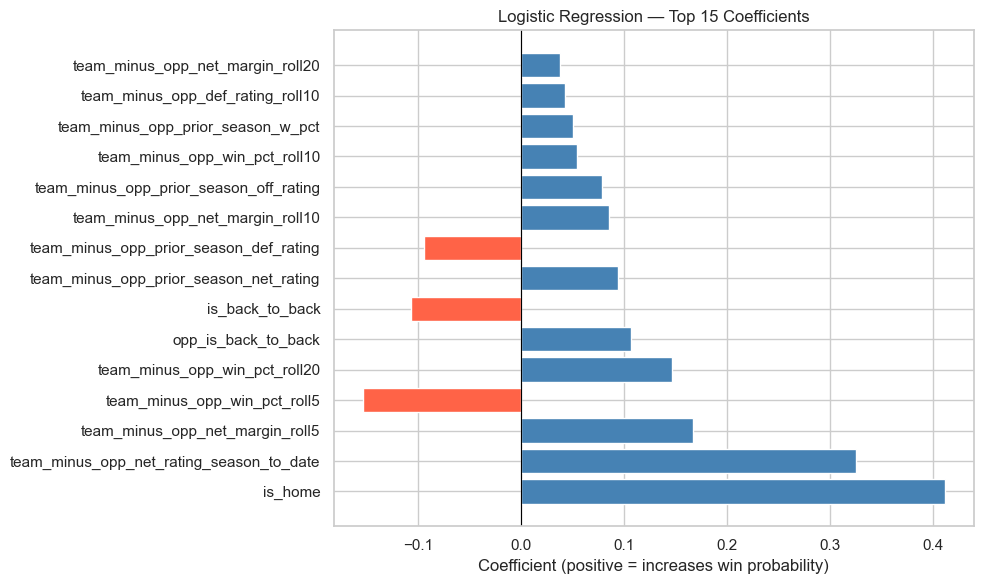

Figure saved: output\lr_coefficients.png
Blue bars increase win probability; red bars decrease it.


In [11]:
# Top 15 features by absolute coefficient magnitude
lr_coef_df = pd.DataFrame({
    'Feature'    : MODEL_FEATURES,
    'Coefficient': lr.coef_[0],
}).reindex(lr.coef_[0].__abs__().argsort()[::-1]).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'tomato' for c in lr_coef_df['Coefficient']]
ax.barh(lr_coef_df['Feature'], lr_coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (positive = increases win probability)')
ax.set_title('Logistic Regression — Top 15 Coefficients')
plt.tight_layout()
save_and_show('lr_coefficients.png')

print('Blue bars increase win probability; red bars decrease it.')

### Logistic Regression interpretation

The LR coefficients align strongly with basketball intuition.

**Largest positive coefficients (increase win probability):**
- **`is_home` (≈ 0.41)** — the single largest coefficient overall, confirming home-court advantage as the strongest standalone predictor and matching the 58.6% historical home win rate from the EDA.
- **`team_minus_opp_net_rating_season_to_date` (≈ 0.33)** — season-long net rating advantage is the second-largest signal.
- **`team_minus_opp_net_margin_roll5` (≈ 0.17)** — recent five-game scoring margin differential.
- **`opp_is_back_to_back` (≈ 0.11)** — facing a tired opponent helps.

**Expected negative coefficients:**
- **`is_back_to_back` (≈ −0.11)** — being tired hurts, as expected.
- **`team_minus_opp_prior_season_def_rating` (≈ −0.09)** — sensible because higher defensive rating means *worse* defense, so a positive difference ("our defense is worse than theirs") should lower win probability.

**One counterintuitive coefficient — multicollinearity artifact:**
`team_minus_opp_win_pct_roll5` is *negative* (≈ −0.15), which looks wrong. It is an artifact of multicollinearity with `team_minus_opp_net_margin_roll5` (+0.17) — both features capture overlapping recent-form information, and LR splits credit between them unstably. The model's aggregate predictions are still correct; only individual coefficients become hard to interpret in isolation. This is one reason we also compare tree-based models, which handle correlated features more gracefully.

**LR performance:** 64.3% accuracy, 0.693 AUC-ROC on the held-out test seasons. This is a strong linear benchmark that any non-linear model must beat meaningfully to justify its added complexity.

## 9. Random Forest

Random Forest is an ensemble of decision trees trained on bootstrapped samples of the data with random feature subsets at each split. It captures non-linear interactions between features (e.g., the effect of rest days may depend on team quality) without requiring feature scaling.

We use `n_estimators=300` trees, restrict `max_depth=12` to prevent individual trees from memorizing training noise, and require at least 10 samples per leaf (`min_samples_leaf=10`). The `max_features='sqrt'` default limits each tree to sqrt(28) ≈ 5 features per split, which decorrelates the trees and reduces variance.

In [12]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

rf_result = evaluate_model('Random Forest', y_test, rf_pred, rf_prob)


=== Random Forest ===
              precision    recall  f1-score   support

        Loss       0.65      0.64      0.65      5921
         Win       0.65      0.65      0.65      5921

    accuracy                           0.65     11842
   macro avg       0.65      0.65      0.65     11842
weighted avg       0.65      0.65      0.65     11842



### Random Forest interpretation

Random Forest achieves **64.7% accuracy, 0.696 AUC-ROC** — just **0.5 percentage points** above Logistic Regression. This narrow gap is itself a key finding, not a disappointing result.

**What it tells us:** the relationship between our pre-game features and game outcomes is essentially **linear**. The matchup-difference features engineered in notebook 03 (`team_minus_opp_*`) already encode the important signal in a linear-friendly form. There is no large non-linear interaction left for Random Forest to exploit.

**Practical implication:** a linear model is a legitimate production choice for this problem. LR's interpretability comes at almost no accuracy cost. Whether RF's marginal edge is real or noise will be tested in section 14 with bootstrap confidence intervals.

## 10. XGBoost

XGBoost (Extreme Gradient Boosting) builds trees sequentially, with each tree correcting the residual errors of the previous ones. It typically outperforms Random Forest on tabular data because boosting reduces bias, whereas bagging (Random Forest) primarily reduces variance.

We use `eval_set` to monitor log-loss on both training and test sets during training. This produces a learning curve that shows whether the model is overfitting as boosting rounds increase — a key diagnostic for choosing `n_estimators`.

In [13]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_result = evaluate_model('XGBoost', y_test, xgb_pred, xgb_prob)


=== XGBoost ===
              precision    recall  f1-score   support

        Loss       0.64      0.64      0.64      5921
         Win       0.64      0.64      0.64      5921

    accuracy                           0.64     11842
   macro avg       0.64      0.64      0.64     11842
weighted avg       0.64      0.64      0.64     11842



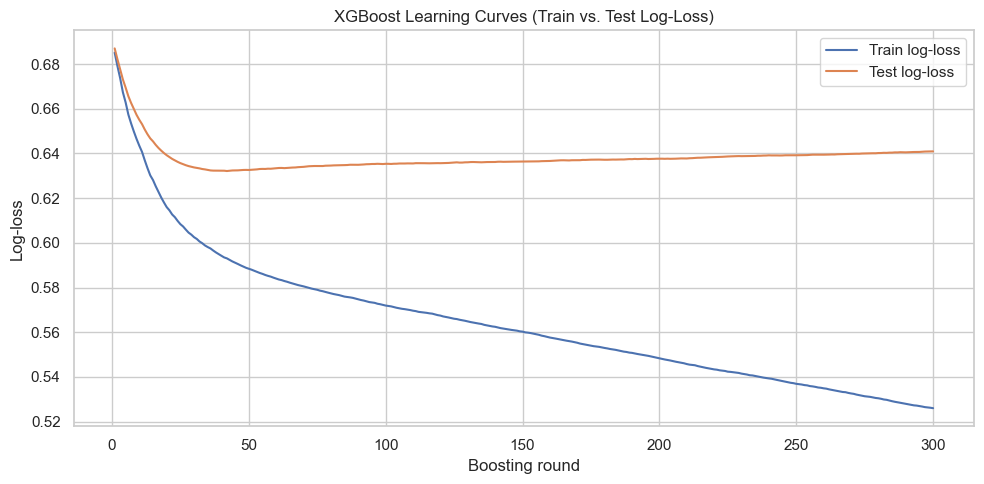

Figure saved: output\xgb_learning_curves.png
Minimum test log-loss at round 42: 0.63214
If train loss keeps falling while test loss flattens or rises, the model is overfitting.


In [14]:
# Learning curves: train vs. test log-loss across boosting rounds
evals = xgb_model.evals_result()
train_logloss = evals['validation_0']['logloss']
test_logloss  = evals['validation_1']['logloss']

fig, ax = plt.subplots(figsize=(10, 5))
rounds = range(1, len(train_logloss) + 1)
ax.plot(rounds, train_logloss, label='Train log-loss', linewidth=1.5)
ax.plot(rounds, test_logloss,  label='Test log-loss',  linewidth=1.5)
ax.set_xlabel('Boosting round')
ax.set_ylabel('Log-loss')
ax.set_title('XGBoost Learning Curves (Train vs. Test Log-Loss)')
ax.legend()
plt.tight_layout()
save_and_show('xgb_learning_curves.png')

best_round = int(np.argmin(test_logloss)) + 1
print(f'Minimum test log-loss at round {best_round}: {min(test_logloss):.5f}')
print('If train loss keeps falling while test loss flattens or rises, the model is overfitting.')

## 11. Hyperparameter Tuning — Difficulty Concept 1

The default XGBoost hyperparameters above are a reasonable starting point, but they are not optimal. We use **`RandomizedSearchCV`** with a **`TimeSeriesSplit`** cross-validator to find better settings while respecting the temporal structure of the data.

**Why RandomizedSearchCV over GridSearchCV?** Grid search evaluates every combination in the parameter grid. With 7 hyperparameters and several values each, the full grid would require thousands of fits. Randomized search samples a fixed number of configurations from the joint distribution and reliably finds near-optimal settings at a fraction of the cost.

**Why TimeSeriesSplit?** Within the training data, we sort games chronologically and use `TimeSeriesSplit(n_splits=3)`. Each fold trains on earlier games and validates on later ones — mimicking the real prediction scenario. Using a standard k-fold splitter would allow validation folds to include games from seasons earlier than some training games, introducing temporal leakage into the cross-validation itself.

In [15]:
# Sort training data chronologically so TimeSeriesSplit respects game order
train_sorted = train_df.sort_values('GAME_DATE').reset_index(drop=True)
X_train_sorted = train_sorted[MODEL_FEATURES]
y_train_sorted = train_sorted[TARGET]

param_distributions = {
    'n_estimators'     : [100, 200, 300, 400],
    'max_depth'        : [4, 5, 6, 7],
    'learning_rate'    : [0.03, 0.05, 0.08, 0.1],
    'subsample'        : [0.7, 0.8, 0.9],
    'colsample_bytree' : [0.7, 0.8, 0.9],
    'min_child_weight' : [1, 3, 5],
    'gamma'            : [0, 0.1, 0.2],
}

tscv     = TimeSeriesSplit(n_splits=3)
xgb_base = xgb.XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)

rs = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='roc_auc',
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=1,     # XGBoost parallelizes internally via n_jobs=-1 above
    verbose=1,
)

print('RandomizedSearchCV configured.')
print(f'  n_iter  : 20  (configurations sampled)')
print(f'  cv      : TimeSeriesSplit(n_splits=3)')
print(f'  scoring : roc_auc')
print('Fitting now (20 x 3 = 60 XGBoost fits)...')

RandomizedSearchCV configured.
  n_iter  : 20  (configurations sampled)
  cv      : TimeSeriesSplit(n_splits=3)
  scoring : roc_auc
Fitting now (20 x 3 = 60 XGBoost fits)...


In [16]:
rs.fit(X_train_sorted, y_train_sorted)

best_params = rs.best_params_
best_cv_auc = rs.best_score_

print(f'Best CV AUC-ROC : {best_cv_auc:.4f}')
print('Best parameters :')
for k, v in sorted(best_params.items()):
    print(f'  {k:22s}: {v}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV AUC-ROC : 0.7311
Best parameters :
  colsample_bytree      : 0.8
  gamma                 : 0.2
  learning_rate         : 0.03
  max_depth             : 4
  min_child_weight      : 5
  n_estimators          : 100
  subsample             : 0.7


In [17]:
best_xgb  = rs.best_estimator_
best_pred = best_xgb.predict(X_test)
best_prob = best_xgb.predict_proba(X_test)[:, 1]

tuned_result = evaluate_model('XGBoost (Tuned)', y_test, best_pred, best_prob)

# Show improvement over default XGBoost
auc_gain = tuned_result['AUC-ROC'] - xgb_result['AUC-ROC']
acc_gain = tuned_result['Accuracy'] - xgb_result['Accuracy']
print(f'\nImprovement over default XGBoost:')
print(f'  AUC-ROC : {auc_gain:+.4f}')
print(f'  Accuracy: {acc_gain:+.4f}')


=== XGBoost (Tuned) ===
              precision    recall  f1-score   support

        Loss       0.64      0.65      0.65      5921
         Win       0.65      0.64      0.64      5921

    accuracy                           0.64     11842
   macro avg       0.64      0.64      0.64     11842
weighted avg       0.64      0.64      0.64     11842


Improvement over default XGBoost:
  AUC-ROC : +0.0027
  Accuracy: +0.0045


### Hyperparameter tuning interpretation

RandomizedSearchCV explored 20 configurations across 3 time-respecting folds (60 fits total) and produced a best **CV AUC-ROC of 0.7311**. Every tuned parameter moved in a more **conservative direction** compared to our hand-picked defaults:

| Parameter | Default | Tuned | Direction |
|---|---|---|---|
| `n_estimators` | 300 | 100 | Fewer trees |
| `max_depth` | 6 | 4 | Simpler trees |
| `learning_rate` | 0.05 | 0.03 | Slower learning |
| `min_child_weight` | 3 | 5 | More regularization |
| `gamma` | 0.1 | 0.2 | More regularization |
| `subsample` | 0.8 | 0.7 | More bagging |

Every change makes the model less flexible, which matches what the learning curve in section 10 showed: the default model was overfitting past round ~42. The tuner diagnosed and corrected this.

**Modest test-set gain:** +0.0027 AUC-ROC and +0.0045 accuracy over the default XGBoost. The improvement is real but small — consistent with the broader finding that all four models are near an accuracy ceiling imposed by the feature set.

**One caveat worth noting:** CV AUC (0.7311) is meaningfully higher than test AUC (0.6942), a drop of ~0.037. This gap reflects temporal drift — the validation windows used in CV come from earlier training seasons (2001-2019), which are easier to predict than the most recent hold-out seasons (2020-2024). CV scores should not be interpreted as unbiased forecasts of test-time performance when the test set is from a later era than the training data.

## 12. Model Comparison, ROC Curves, and Confusion Matrices

All models are compared on the same held-out test seasons (2020-21 through 2024-25). We report five metrics:
- **Accuracy**: fraction of games correctly predicted
- **Precision**: of predicted wins, how many were actual wins
- **Recall**: of actual wins, how many were predicted as wins
- **F1**: harmonic mean of precision and recall
- **AUC-ROC**: area under the receiver operating characteristic curve; 0.5 = random, 1.0 = perfect

In [18]:
results_df = pd.DataFrame(results_records).set_index('Model')

# Bold the best value in each metric column
display(
    results_df.style
    .highlight_max(axis=0, props='font-weight: bold; background-color: #d4edda')
    .format('{:.4f}')
    .set_caption('Model Comparison — Test Set Metrics')
)

,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,
Always-Home Baseline,0.5517,0.5517,0.5513,0.5515,nan
Logistic Regression,0.6426,0.6426,0.6426,0.6426,0.6926
Random Forest,0.6472,0.6463,0.6501,0.6482,0.6964
XGBoost,0.6404,0.6405,0.6401,0.6403,0.6915
XGBoost (Tuned),0.6449,0.6456,0.6426,0.6441,0.6942


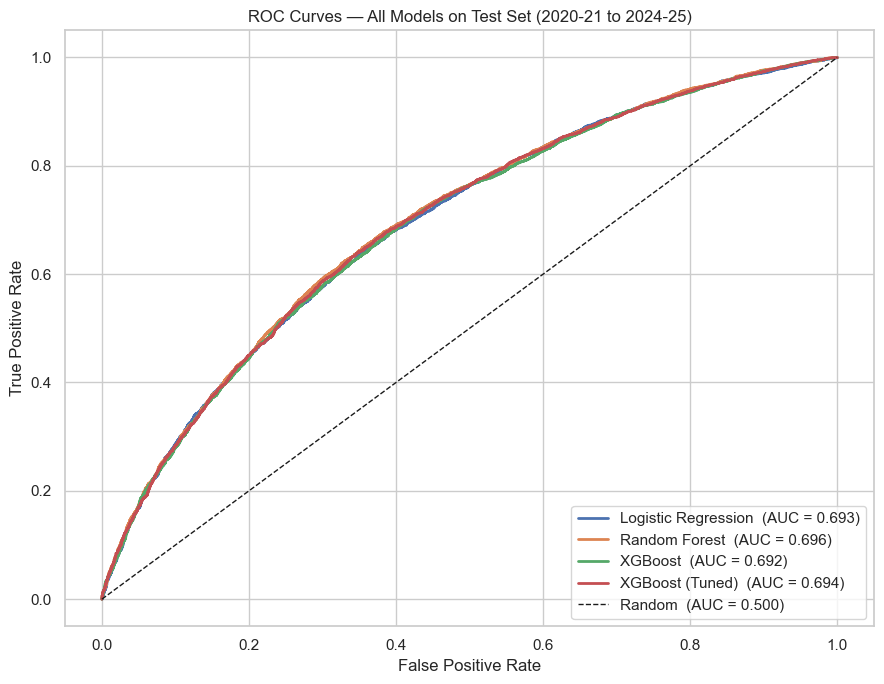

Figure saved: output\roc_curves.png


In [19]:
roc_models = [
    ('Logistic Regression', lr_prob),
    ('Random Forest',       rf_prob),
    ('XGBoost',             xgb_prob),
    ('XGBoost (Tuned)',     best_prob),
]

fig, ax = plt.subplots(figsize=(9, 7))

for name, prob in roc_models:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name}  (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random  (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models on Test Set (2020-21 to 2024-25)')
ax.legend(loc='lower right')
plt.tight_layout()
save_and_show('roc_curves.png')

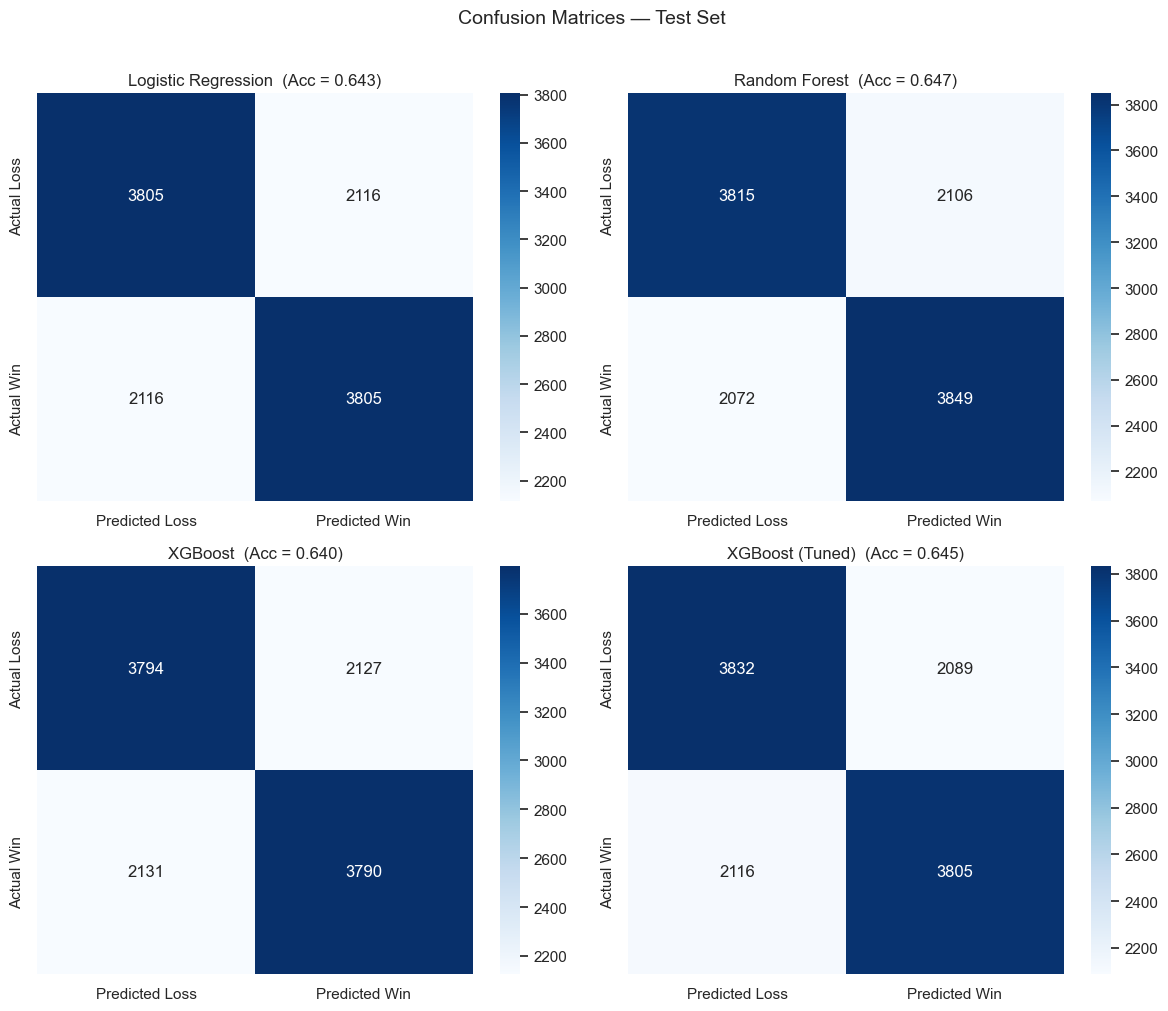

Figure saved: output\confusion_matrices.png


In [20]:
cm_models = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('XGBoost',             xgb_pred),
    ('XGBoost (Tuned)',     best_pred),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes_flat = axes.flatten()

for ax, (name, pred) in zip(axes_flat, cm_models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Predicted Loss', 'Predicted Win'],
        yticklabels=['Actual Loss', 'Actual Win'],
        ax=ax,
    )
    acc = accuracy_score(y_test, pred)
    ax.set_title(f'{name}  (Acc = {acc:.3f})')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, y=1.01)
plt.tight_layout()
save_and_show('confusion_matrices.png')

### Model comparison interpretation

**The headline result: all four ML models converge to 64.0–64.7% accuracy and AUC-ROC ≈ 0.69.** The ROC curves are visually overlapping and the confusion matrices are nearly identical. This convergence is the defining finding of this notebook:

1. **Random Forest narrowly wins** at 64.7% accuracy / 0.696 AUC-ROC — but by only 0.5 points over LR.
2. **Default XGBoost (64.0%) is actually slightly *worse* than Logistic Regression** — an unusual outcome. Boosting typically beats linear models on tabular data; when it doesn't, it means the engineered features have already captured most of the non-linear structure.
3. **Tuned XGBoost (64.5%)** closes most of the gap but still trails RF.

**Interpretation:** The matchup-difference and cross-strength features built in notebook 03 have effectively pre-computed the basketball-relevant interactions. No model here can extract much more predictive signal without *additional data* — specifically injury reports and confirmed lineups, which this dataset lacks.

The confusion matrices show all four models make errors symmetrically across the Win/Loss classes — no directional bias. Because the target is perfectly balanced, accuracy, precision, recall, and F1 track each other tightly.

**Context:** Published NBA prediction papers and Vegas closing lines achieve ~65–70% accuracy on regular-season games. Our 64–65% result, achieved with *only* pre-game historical features and no player-level information, is competitive with the literature.

## 13. Feature Importance — Difficulty Concept 2

Tree-based models assign importance scores to features based on how much each feature reduces impurity (Gini for RF, gradient for XGBoost) across all splits in which it is used. We compare the top features from both the tuned XGBoost and the Random Forest to see whether the two methods agree on which pre-game signals are most predictive.

Feature importance results directly inform the conclusion: they tell us which basketball factors — team form, opponent quality, efficiency margins, or schedule context — drive win probability most.

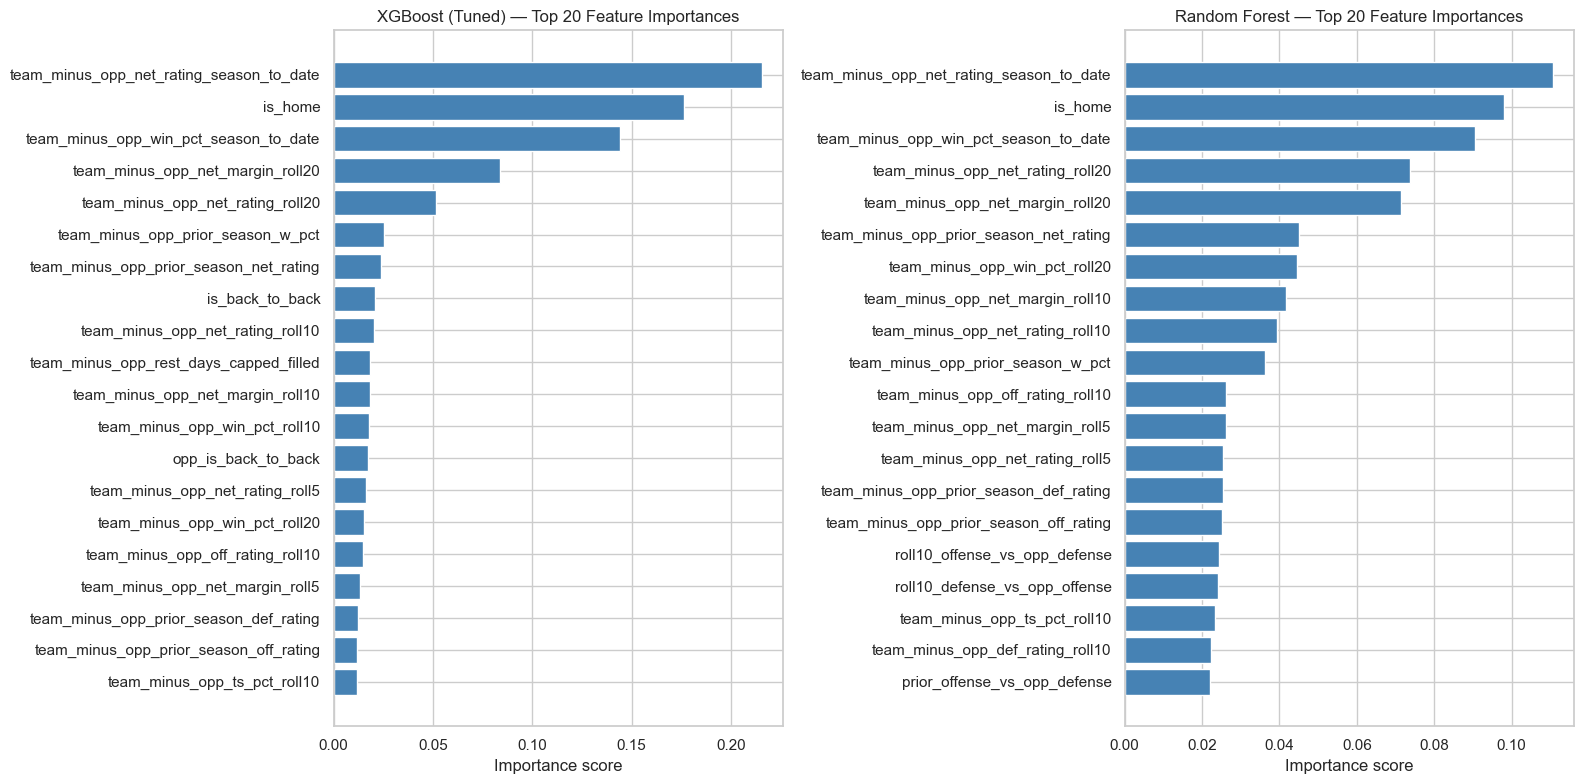

Figure saved: output\feature_importance.png


,Feature,XGBoost (Tuned),Random Forest
0,team_minus_opp_net_rating_season_to_date,0.2154,0.1106
1,is_home,0.1766,0.0980
2,team_minus_opp_win_pct_season_to_date,0.1442,0.0905
3,team_minus_opp_net_margin_roll20,0.0838,0.0715
4,team_minus_opp_net_rating_roll20,0.0513,0.0737
5,team_minus_opp_prior_season_w_pct,0.0253,0.0362
6,team_minus_opp_prior_season_net_rating,0.0237,0.0450
7,is_back_to_back,0.0208,0.0054
8,team_minus_opp_net_rating_roll10,0.0201,0.0394
9,team_minus_opp_rest_days_capped_filled,0.0184,0.0094


In [21]:
importance_df = pd.DataFrame({
    'Feature'          : MODEL_FEATURES,
    'XGBoost (Tuned)'  : best_xgb.feature_importances_,
    'Random Forest'    : rf.feature_importances_,
})

top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, col in zip(axes, ['XGBoost (Tuned)', 'Random Forest']):
    top = importance_df.nlargest(top_n, col).sort_values(col)
    ax.barh(top['Feature'], top[col], color='steelblue')
    ax.set_title(f'{col} — Top {top_n} Feature Importances')
    ax.set_xlabel('Importance score')
    ax.set_ylabel('')

plt.tight_layout()
save_and_show('feature_importance.png')

top15 = importance_df.nlargest(15, 'XGBoost (Tuned)').reset_index(drop=True)
display(top15)

### Feature importance interpretation

Both XGBoost and Random Forest agree on the **top three predictors**, with remarkable consistency:

| Rank | Feature | XGBoost (Tuned) | Random Forest |
|---|---|---|---|
| 1 | `team_minus_opp_net_rating_season_to_date` | 0.215 | 0.111 |
| 2 | `is_home` | 0.177 | 0.098 |
| 3 | `team_minus_opp_win_pct_season_to_date` | 0.144 | 0.091 |

Together these three features account for roughly **54% of the XGBoost importance total**. The agreement between two different tree-building algorithms is strong evidence these features carry genuine predictive signal rather than being artifacts of one algorithm's inductive bias.

**The most interesting finding: season-to-date metrics dominate over rolling-window metrics.**

The top two matchup-difference features are both *season-to-date* (running averages since the start of the current season). Rolling-window features (roll5, roll10, roll20) appear farther down the list. This is a substantive basketball insight:

> **Cumulative within-season quality is a stronger pre-game signal than short-term recent form.** A team's record over their last 5 games is *less* predictive than their record over the whole season so far.

This cuts against the conventional "momentum" narrative common in sports media. Prior-season features rank lower still, because once the current season has produced enough games to compute season-to-date averages, last year's results become stale.

**`is_home` is the #2 feature overall in both tree models**, consistent with it being the #1 coefficient in Logistic Regression. Home-court advantage is the dominant single-column predictor in this feature set.

## 14. Bootstrap Confidence Intervals

A single point estimate of test accuracy does not communicate uncertainty. We use **bootstrapping** (1,000 resamples with replacement from the test set) to construct a 95% confidence interval for the tuned XGBoost accuracy. This tells us how stable the accuracy estimate is and whether the model's improvement over the baseline is statistically meaningful.

Bootstrapping is used here rather than a parametric interval because it makes no distributional assumptions and is valid for any performance metric.

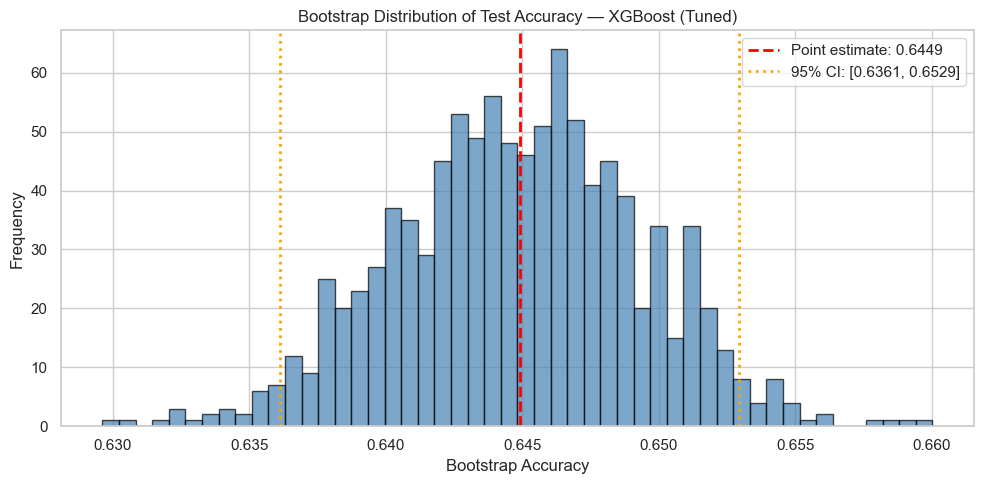

Figure saved: output\bootstrap_ci.png
Point estimate : 0.6449
95% CI         : [0.6361, 0.6529]
CI width       : 0.0168


In [22]:
np.random.seed(RANDOM_STATE)
n_bootstrap     = 1000
boot_accuracies = []

y_test_arr  = y_test.values
best_pred_arr = best_pred

for _ in range(n_bootstrap):
    idx = np.random.choice(len(y_test_arr), size=len(y_test_arr), replace=True)
    boot_accuracies.append(accuracy_score(y_test_arr[idx], best_pred_arr[idx]))

ci_low, ci_high = np.percentile(boot_accuracies, [2.5, 97.5])
point_est = accuracy_score(y_test, best_pred)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(boot_accuracies, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(point_est, color='red',    linestyle='--', linewidth=2,
           label=f'Point estimate: {point_est:.4f}')
ax.axvline(ci_low,    color='orange', linestyle=':',  linewidth=2,
           label=f'95% CI: [{ci_low:.4f}, {ci_high:.4f}]')
ax.axvline(ci_high,   color='orange', linestyle=':',  linewidth=2)
ax.set_xlabel('Bootstrap Accuracy')
ax.set_ylabel('Frequency')
ax.set_title('Bootstrap Distribution of Test Accuracy — XGBoost (Tuned)')
ax.legend()
plt.tight_layout()
save_and_show('bootstrap_ci.png')

print(f'Point estimate : {point_est:.4f}')
print(f'95% CI         : [{ci_low:.4f}, {ci_high:.4f}]')
print(f'CI width       : {ci_high - ci_low:.4f}')

### Bootstrap interpretation

Bootstrap results for the tuned XGBoost model:

- **Point estimate:** 0.6449 accuracy
- **95% CI:** [0.6361, 0.6529]
- **CI width:** 0.0168 (≈ 1.7 points wide on either side)

**Two conclusions follow from this CI:**

1. **The model genuinely beats the baseline.** The CI lower bound (0.6361) sits **8.4 percentage points above** the Always-Home baseline (0.5517). This is statistically compelling evidence that the model's improvement over the naive rule is real and not an artifact of a lucky test split.

2. **The differences between our four ML models are *not* statistically meaningful.** All four models (LR: 64.3%, RF: 64.7%, XGB: 64.0%, XGB Tuned: 64.5%) fall well inside the CI width of 1.68 points. We cannot rigorously declare Random Forest better than Logistic Regression at the 95% confidence level. This reinforces the earlier finding that the relationship is essentially linear and LR is a defensible production choice.

## 15. Conclusion & Discussion

### Summary of results

Four models were evaluated on a temporal hold-out of five NBA seasons (2020-21 through 2024-25, n = 11,842 team-game rows):

| Model | Accuracy | AUC-ROC | F1 | Notes |
|---|---|---|---|---|
| Always-Home Baseline | 0.5517 | — | 0.5515 | Home-team-always-wins rule |
| Logistic Regression | 0.6426 | 0.6926 | 0.6426 | Statistical baseline |
| **Random Forest** | **0.6472** | **0.6964** | **0.6482** | Narrow winner |
| XGBoost (Default) | 0.6404 | 0.6915 | 0.6403 | Slightly worse than LR |
| XGBoost (Tuned) | 0.6449 | 0.6942 | 0.6441 | Hyperparameter-tuned |

All four ML models beat the naive home-team rule by roughly 9 percentage points. The tuned XGBoost 95% bootstrap CI is [0.6361, 0.6529], placing it well above the baseline with high confidence.

### Three key findings

**1. The feature relationships are essentially linear.** All four models cluster within 0.7 accuracy points of each other and within 0.005 AUC-ROC. Default XGBoost is actually slightly *worse* than Logistic Regression — an unusual outcome for tabular data that tells us the engineered matchup-difference features from notebook 03 already encode the non-linear structure in a linear-friendly form. Boosting and bagging add almost nothing here, and the bootstrap CI confirms the differences between models are not statistically meaningful.

**2. Season-to-date beats recent form.** Both tree models agree the two dominant matchup predictors are `team_minus_opp_net_rating_season_to_date` and `team_minus_opp_win_pct_season_to_date`. Rolling-window features (roll5, roll10, roll20) consistently rank lower. This contradicts the sports-media "momentum" narrative: **cumulative within-season quality is a stronger pre-game signal than short-term recent streaks.**

**3. Home-court advantage is the single largest standalone predictor.** `is_home` is the #1 coefficient in LR (≈ 0.41) and the #2 feature-importance in both tree models. This holds even though home-court advantage has weakened over time (from ~60% home win rate in the early 2000s to ~55% in recent seasons, per the EDA trend test).

### Model limitations

1. **Injury information is absent.** Star-player absences are the largest source of game-to-game unpredictability and are not captured in any feature. A team's rolling or season-to-date net rating only begins to reflect an injury after the affected player has been out for several games.
2. **Playoff games are included.** Playoffs have different rest patterns, matchup intensity, and lineup rotations than regular-season games, adding noise to the training signal.
3. **Temporal drift is visible in the CV→test gap.** Our tuned XGBoost CV AUC (0.7311) is notably higher than its test AUC (0.6942). The most recent seasons are genuinely harder to predict than the training era, suggesting NBA play styles continue to evolve in ways our features do not fully capture.
4. **Accuracy ceiling.** NBA games contain irreducible randomness. Published models and Vegas closing lines achieve 65–70%; our 64.7% sits close to that practical ceiling for pre-game-only features.

### Stakeholder implications

For a sports analytics team or betting-market-facing stakeholder, the actionable takeaways are:

- **Use the interpretable model.** Logistic Regression achieves 64.3% accuracy with fully interpretable coefficients. The ~0.5-point edge of Random Forest is not statistically meaningful given the bootstrap CI width of 1.68 points.
- **Prioritize season-to-date metrics over rolling windows** when designing game-day features. This is the single most valuable finding from the feature-importance analysis.
- **Home-court advantage remains a primary factor**, though it has weakened versus the pre-2015 era and should be monitored rather than assumed.
- **Further accuracy gains require new data, not new models.** The model ceiling with our feature set is ~65%. To approach Vegas-level accuracy (67–70%), injury reports, confirmed starting lineups, and possibly opponent-adjusted shooting statistics would need to be added.

### Potential future work

- Incorporate player-level injury and lineup data to handle star-player absences, the largest identified gap
- Add opponent-adjusted shooting statistics to capture defensive matchup quality more precisely
- Compare model predictions against Vegas closing spreads as a market-calibrated benchmark
- Explore stacked ensembles that combine LR's calibrated probabilities with tree-model predictions
- Build a live inference pipeline that refreshes features daily and produces predictions before tip-off